# Pythonizing Vincent!

In [1]:
import numpy as np
from typing import Union, Optional


# ------------------------------------------------------------
# 1) Ppi: build the orthogonal matrix V from first-order Pis
# ------------------------------------------------------------

def Ppi(Pi: Union[np.ndarray, list]) -> np.ndarray:
    """
    Python/Numpy port of the R function Ppi(Pi).

    Parameters
    ----------
    Pi : array-like of shape (N,)
        First-order inclusion probabilities, 0 < Pi_i < 1,
        sum(Pi) must be (approximately) an integer.

    Returns
    -------
    V : ndarray of shape (N, n)
        Orthogonal matrix associated to the DSD construction.
    """
    Pi = np.asarray(Pi, dtype=float).ravel()
    N = Pi.size

    # --- Error checks ---
    if N < 2:
        raise ValueError(
            "The sampling designs should be defined on a set of more than "
            "one element. (length(Pi) > 1)"
        )

    if np.any(Pi <= 0) or np.any(Pi >= 1):
        raise ValueError("Pi is not a vector of probabilities (0 < p < 1).")

    sum_pi_rounded = round(Pi.sum(), 9)
    n_int = int(sum_pi_rounded)
    if int(round(sum_pi_rounded, 9)) - sum_pi_rounded != 0:
        raise ValueError(
            "The sum of the first order inclusion probabilities "
            "should be an integer (up to rounding)."
        )

    # --- Main algorithm ---
    s_vals = np.zeros(N, dtype=float)
    c_vals = np.zeros(N, dtype=float)
    alpha = np.zeros(N, dtype=float)

    # kr will store the indices (0-based) where cumulative sum crosses integers
    if n_int <= 0:
        raise ValueError("Sum of Pi must be at least 1.")
    kr = [None] * n_int

    cum_sum = 0.0
    r = 1          # current integer threshold
    r_prev = 0     # last integer that was crossed

    for k in range(N):
        prev_sum = cum_sum
        cum_sum += Pi[k]

        if cum_sum >= r:  # crossed integer r
            if r <= n_int:
                alpha[k] = r - prev_sum
                kr[r - 1] = k   # store 0-based index
                val = np.sqrt((1.0 - Pi[k]) / (1.0 - alpha[k]))
                s_vals[k] = np.round(val, 8)
                r_prev = r
                r += 1
        else:
            denom = (r_prev + 1 - prev_sum)
            val = np.sqrt(Pi[k] / denom)
            s_vals[k] = np.round(val, 15)

        c_vals[k] = np.sqrt(1.0 - s_vals[k] ** 2)

    # Patch: ensure last crossing index corresponds to last unit (like R hack)
    # If some entries of kr are still None, set the last one to N-1.
    if any(x is None for x in kr):
        kr[-1] = N - 1
    # For safety, also replace any remaining None by the last index
    last_index = kr[-1]
    kr = [last_index if x is None else x for x in kr]

    # Use sample size n_int as number of columns (simplified vs. R hack)
    r_prev = n_int

    # --- Build V ---
    V = np.zeros((N, r_prev), dtype=float)
    V[0, 0] = 1.0

    # In R: V[kr[r] + 1, r + 1] = 1 for r in 1:(r_prev-1)
    # Here r_idx corresponds to r-1 in R, and we use 0-based indices.
    if r_prev - 1 != 0:
        for r_idx in range(1, r_prev):
            kpos = kr[r_idx - 1]  # 0-based index for row
            V[kpos + 1, r_idx] = 1.0

    # Apply Givens-like rotations
    for k in range(N - 1):
        L = V[k, :].copy()
        M = V[k + 1, :].copy()
        V[k, :] = s_vals[k] * L - c_vals[k] * M
        V[k + 1, :] = c_vals[k] * L + s_vals[k] * M

    return V


# ------------------------------------------------------------
# 2) DSD sampling (real and complex versions)
# ------------------------------------------------------------

def Drawing_Dsd(
    v: Union[np.ndarray, list],
    s: int = 1,
    B: bool = False,
    seed: Optional[int] = None,
):
    """
    Python/Numpy port of the R function Drawing_Dsd(v, s=1, B=FALSE, seed=NULL).

    Parameters
    ----------
    v : array-like, shape (N, n)
        Matrix of (real or complex) vectors used in DSD.
    s : int, default 1
        Number of samples (replicates).
    B : bool, default False
        If True: return 0/1 indicator vector(s).
        If False: return indices of selected units (1-based, to match R).
    seed : int or None
        Seed for reproducibility.

    Returns
    -------
    If s == 1:
        1D array of length N (if B=True) or selected indices (if B=False).
    If s > 1:
        2D array of shape (N, s) (if B=True) or (n, s) with indices per sample.
    """
    v = np.asarray(v)
    rng = np.random.default_rng(seed)

    if np.iscomplexobj(v):
        return _dsd_sampling_mult_complex(v, s, B, rng)
    else:
        return _dsd_sampling_mult(v, s, B, rng)


# ---------------------- helpers: real case ---------------------- #

def _dsd_sampling_mult(
    v: np.ndarray,
    s: int,
    B: bool,
    rng: np.random.Generator,
):
    v = np.asarray(v, dtype=float)
    if v.ndim == 1:
        v = v[:, None]  # treat as (N,1)

    if s == 1:
        return _dsd_sampling_01_B_C(v, B, rng)
    else:
        samples = [_dsd_sampling_01_B_C(v, B, rng) for _ in range(s)]
        # stack as columns like R's replicate (N x s)
        return np.column_stack(samples)


def _dsd_sampling_01_B_C(
    v: np.ndarray,
    B: bool = True,
    rng: Optional[np.random.Generator] = None,
):
    """
    Real-valued version of .dsd_sampling_01_B_C in R.
    """
    v = np.asarray(v, dtype=float)
    if v.ndim == 1:
        v = v[:, None]

    N, n = v.shape
    echant = np.zeros(N, dtype=int)

    if rng is None:
        rng = np.random.default_rng()
    ref = rng.random(n)

    # Step 1: first element
    w = v.copy()

    pi1 = np.einsum("ij,ij->i", v, v)  # diag(v %*% t(v))
    total = 0.0
    i = -1

    while total < ref[0]:
        i += 1
        if i >= N:
            raise RuntimeError("Sampling failed in first step (real case).")
        total += pi1[i] / n
    echant[i] = 1

    l = v[i, :]
    norm_l = np.sqrt(np.dot(l, l))
    if norm_l == 0:
        raise ValueError("Encountered zero-norm vector in real DSD.")
    e1 = l / norm_l

    # Step 2: remaining n-1 elements
    for j in range(n - 1):
        r = n - (j + 1)
        inter = v @ e1  # (N,)
        pi1 = pi1 - inter * inter
        pi2 = pi1 / r

        total = 0.0
        i = -1
        while total < ref[j + 1]:
            i += 1
            if i >= N:
                raise RuntimeError("Sampling failed in step 2 (real case).")
            total += pi2[i]
        echant[i] = 1

        # Update w and e1 (Gram-Schmidt-like update)
        proj = w @ e1                      # shape (N,)
        w = w - np.outer(proj, e1)         # (N,n)
        L = w[i, :]
        norm_L = np.sqrt(np.dot(L, L))
        if norm_L == 0:
            raise ValueError("Encountered zero-norm vector in real DSD.")
        e1 = L / norm_L

    if B:
        # 0/1 vector -> same as R "echant"
        return echant
    else:
        # indices (1-based, like in R: (1:N)[echant==1])
        return np.nonzero(echant == 1)[0] + 1


# -------------------- helpers: complex case --------------------- #

def _dsd_sampling_mult_complex(
    v: np.ndarray,
    s: int,
    B: bool,
    rng: np.random.Generator,
):
    v = np.asarray(v, dtype=np.complex128)
    if v.ndim == 1:
        v = v[:, None]

    if s == 1:
        return _dsd_sampling_01_B_C_complex(v, B, rng)
    else:
        samples = [_dsd_sampling_01_B_C_complex(v, B, rng) for _ in range(s)]
        return np.column_stack(samples)


def _dsd_sampling_01_B_C_complex(
    v: np.ndarray,
    B: bool = True,
    rng: Optional[np.random.Generator] = None,
):
    """
    Complex-valued version of .dsd_sampling_01_B_C_complex in R.
    """
    v = np.asarray(v, dtype=np.complex128)
    if v.ndim == 1:
        v = v[:, None]

    N, n = v.shape
    echant = np.zeros(N, dtype=int)

    if rng is None:
        rng = np.random.default_rng()
    ref = rng.random(n)

    w = v.copy()

    # pi1 = Re( diag( v %*% t(Conj(v)) ) )
    pi1 = np.real(np.einsum("ij,ij->i", v, np.conjugate(v)))

    if np.any(pi1 < 0) or np.any(pi1 >= 1):
        raise ValueError(
            "The matrix v given as input doesn't suit the expected input "
            "(cf. pgd / periodic_dsd)."
        )

    # Step 1: first element
    total = 0.0
    i = -1

    while total < ref[0]:
        i += 1
        if i >= N:
            raise RuntimeError("Sampling failed in first step (complex case).")
        total += pi1[i] / n
    echant[i] = 1

    M = v[i, :]
    norm_M = np.sqrt(np.real(np.vdot(M, M)))
    if norm_M == 0:
        raise ValueError("Encountered zero-norm vector in complex DSD.")
    e1 = M / norm_M

    # Step 2: remaining n-1 elements
    for j in range(n - 1):
        r = n - (j + 1)

        # inter <- v %*% Conj(e1)
        inter = v @ np.conjugate(e1)           # (N,)
        pi1 = pi1 - np.real(inter * np.conjugate(inter))
        pi2 = np.real(pi1 / r)

        total = 0.0
        i = -1
        while total < ref[j + 1]:
            i += 1
            if i >= N:
                raise RuntimeError("Sampling failed in step 2 (complex case).")
            total += pi2[i]
        echant[i] = 1

        # w <- w - (projection on e1)
        proj = w @ np.conjugate(e1)           # (N,)
        w = w - np.outer(proj, e1)            # (N, n)

        L = w[i, :]
        norm_L = np.sqrt(np.real(np.vdot(L, L)))
        if norm_L == 0:
            raise ValueError("Encountered zero-norm vector in complex DSD.")
        e1 = L / norm_L

    if B:
        return echant
    else:
        # Return 1-based indices, to match the R function
        return np.nonzero(echant == 1)[0] + 1

In [2]:
import numpy as np
from typing import Optional, Union


def spec(omega: np.ndarray, M: int, pi: Union[np.ndarray, list], spectre=100) -> np.ndarray:
    """
    Python/Numpy port of the R function:

        spec <- function(omega, M, pi, spectre = 100)

    Parameters
    ----------
    omega : array-like, shape (M, N)
        Omega matrix (same role as in the R code).
    M : int
        Integer (usually sum(pi)).
    pi : array-like, shape (N,)
        First-order inclusion probabilities.
    spectre : 100 or array-like of length M
        If 100 (default), the spectrum is constructed as in the R code.
        Otherwise, used directly as the initial spectrum.

    Returns
    -------
    mat_spectre : ndarray, shape (M, N)
    """
    pi = np.asarray(pi, dtype=float).ravel()
    N = pi.size
    omega = np.asarray(omega, dtype=float)
    if omega.shape != (M, N):
        raise ValueError("omega must have shape (M, N)")

    mat_spectre = np.zeros((M, N), dtype=float)
    pi_down = np.sort(pi)[::-1]
    mu = pi.sum()

    # --- Build initial spectrum (last column) if needed ---
    if (np.isscalar(spectre) and spectre == 100) or (
        not np.isscalar(spectre)
        and len(np.atleast_1d(spectre)) == 1
        and np.atleast_1d(spectre)[0] == 100
    ):
        spectre_vec = np.zeros(M, dtype=float)
        cumsum_1 = 0.0
        lam = 0.0

        # j in 1:(M-1)  ->  jR = j+1
        for j in range(M - 1):
            jR = j + 1
            A = max(lam, mu - cumsum_1 - (M - jR))
            B = 1.0

            # i in 1:(M-jR)
            for iR in range(1, M - jR + 1):
                # sum(pi_down[1:(M-j-i+1)]) in R
                t_idx = M - jR - iR + 1  # always >= 1 here
                s_down = pi_down[:t_idx].sum()
                B = min(B, (mu - cumsum_1 - s_down) / iR)

            B = min(B, (mu - cumsum_1) / (M - jR + 1))
            spectre_vec[j] = A + omega[j, N - 1] * (B - A)
            lam = spectre_vec[j]
            cumsum_1 += spectre_vec[j]

        # last component
        spectre_vec[M - 1] = mu - spectre_vec[: M - 1].sum()

    else:
        spectre_arr = np.asarray(spectre, dtype=float).ravel()
        if spectre_arr.size != M:
            raise ValueError("spectre must have length M")
        spectre_vec = spectre_arr

    mat_spectre[:, N - 1] = spectre_vec

    # --- Backward recursion for other columns (k in (N-1):1) ---
    for kR in range(N - 1, 0, -1):  # kR = N-1, ..., 1
        startR = max(1, M - kR + 1)
        lambda1 = mat_spectre[:, kR].copy()     # column k+1 in R
        lambda2 = mat_spectre[:, kR - 1].copy() # column k in R

        # j in start:M
        for jR in range(startR, M + 1):
            # A = max(0, lambda1[j-1], sum(lambda1[1:j]) - sum(lambda2[0:(j-1)]) - pi_down[k+1])
            if jR >= 2:
                lam_prev = lambda1[jR - 2]
            else:
                lam_prev = 0.0

            sum_l1 = lambda1[:jR].sum()
            sum_l2 = lambda2[: jR - 1].sum() if jR > 1 else 0.0
            A = max(0.0, lam_prev, sum_l1 - sum_l2 - pi_down[kR])  # pi_down[k+1] -> index kR

            # Build B_1
            B_list = []
            for iR in range(jR, M + 1):
                prem = 0.0
                deux = 0.0
                trois = lambda2[: jR - 1]

                # prem = pi_down[(M-i+1):k] if (M-i+1) <= k
                if (M - iR + 1) <= kR:
                    start_idx = M - iR + 1  # 1-based
                    prem = pi_down[start_idx - 1 : kR].sum()

                # deux = lambda1[j:(i-1)] if j <= i-1
                if jR <= (iR - 1):
                    deux = lambda1[jR - 1 : iR - 1].sum()

                B_val = prem - deux - trois.sum()
                B_list.append(B_val)

            B_inner = min(B_list) if B_list else float("inf")
            B = min(lambda1[jR - 1], B_inner)

            mat_spectre[jR - 1, kR - 1] = A + omega[jR - 1, kR - 1] * (B - A)
            lambda2[jR - 1] = mat_spectre[jR - 1, kR - 1]

    return mat_spectre


def CaDsd(
    pi: Union[np.ndarray, list],
    M: Optional[int] = None,
    omega: Optional[np.ndarray] = None,
    rho: Optional[np.ndarray] = None,
    spectre=100,
    U: Optional[np.ndarray] = None,
    option: bool = True,
):
    """
    Python/Numpy port of the R function:

        CaDsd <- function(omega=matrix(0.5,M,length(pi)),
                          rho=matrix(0.5,M,length(pi)-1),
                          M=round(sum(pi),7),
                          pi,
                          spectre=100,
                          U=diag(M),
                          option=TRUE)

    Parameters
    ----------
    pi : array-like, length N
    M : int or None
        If None, set to round(sum(pi), 7) as in R.
    omega : array-like, shape (M, N), default 0.5
    rho : array-like, shape (M, N-1), default 0.5
    spectre : passed to spec(...)
    U : initial unitary matrix, shape (M, M); default identity.
    option : kept for signature compatibility (not used here).

    Returns
    -------
    dict with keys: "K", "spectrum", "EigenBasis"
    """
    pi = np.asarray(pi, dtype=float).ravel()
    N = pi.size

    # M default
    if M is None:
        M = int(round(pi.sum(), 7))
    if int(M) != M:
        raise ValueError("M should be an integer")
    M = int(M)

    # Defaults for omega and rho
    if omega is None:
        omega = 0.5 * np.ones((M, N), dtype=float)
    else:
        omega = np.asarray(omega, dtype=float)
        if omega.shape != (M, N):
            raise ValueError("omega must have shape (M, N)")

    if rho is None:
        rho = 0.5 * np.ones((M, N - 1), dtype=float)
    else:
        rho = np.asarray(rho, dtype=float)
        if rho.shape != (M, N - 1):
            raise ValueError("rho must have shape (M, N-1)")

    # Convert rho to angles and compute spectrum
    rho = np.round(rho * 2 * np.pi, 7)
    mat_spectre = np.round(spec(omega, M, pi, spectre), 7)

    pi_down = np.sort(pi)[::-1]

    # U default
    if U is None:
        U = np.eye(M, dtype=complex)
    else:
        U = np.asarray(U, dtype=complex)
        if U.shape != (M, M):
            raise ValueError("U must have shape (M, M)")

    # phi = sqrt(pi_down[1])*U[,1] (1st column, 1-based)
    phi = np.round(np.sqrt(pi_down[0]) * U[:, [0]], 7)  # shape (M, 1)
    ens = np.arange(1, M + 1, dtype=int)               # 1..M

    # Main loop over k = 2..N
    for kR in range(2, N + 1):
        # V = diag(complex(argument = rho[,k-1], modulus = 1))
        rho_col = rho[:, kR - 2]
        V = np.diag(np.exp(1j * rho_col))

        lambda1 = mat_spectre[:, kR - 1].copy()
        lambda2 = mat_spectre[:, kR - 2].copy()

        E1 = ens.copy().tolist()
        E2 = ens.copy().tolist()

        # Matching equal eigenvalues between lambda2 and lambda1
        for jR in ens:
            val = lambda2[jR - 1]
            if not E1:
                break
            lam1_E1 = lambda1[np.array(E1) - 1]
            matches = np.where(lam1_E1 == val)[0]
            if matches.size > 0:
                # remove jR from E2
                E2 = [x for x in E2 if x != jR]
                # remove the first match from E1
                del E1[matches[0]]

        E1_arr = np.array(E1, dtype=int)
        E2_arr = np.array(E2, dtype=int)
        E1_ = M + 1 - E1_arr
        E2_ = M + 1 - E2_arr
        r = len(E1_)

        # Permutation matrices sigma1, sigma2
        if r != M:
            E1_c = ens[~np.isin(ens, E1_)]
            E2_c = ens[~np.isin(ens, E2_)]

            E1_ = np.concatenate([np.sort(E1_), np.sort(E1_c)])
            E2_ = np.concatenate([np.sort(E2_), np.sort(E2_c)])

            sigma1 = np.eye(M, dtype=complex)[E1_ - 1, :]
            sigma2 = np.eye(M, dtype=complex)[E2_ - 1, :]
        else:
            sigma1 = np.eye(M, dtype=complex)
            sigma2 = np.eye(M, dtype=complex)

        if r != 0:
            # R = diag(r)[r:1,] %*% cbind(lambda2[E2], lambda1[E1])
            lambda2_E2 = lambda2[E2_arr - 1]
            lambda1_E1 = lambda1[E1_arr - 1]
            R = np.column_stack([lambda2_E2, lambda1_E1]).astype(complex)
            R = R[::-1, :]  # reverse rows

            v = np.zeros(r, dtype=complex)
            w = np.zeros(r, dtype=complex)

            for i in range(r):
                # v-part
                v1 = R[i, 0] - R[:, 1]
                v2 = R[i, 0] - R[:, 0]
                v2[i] = 1.0 + 0j
                order = np.argsort(np.abs(v1))
                v1s = v1[order]
                v2s = v2[order]
                ratio_prod = np.prod(v1s / v2s)
                v[i] = np.round(np.sqrt(-ratio_prod), 7)

                # w-part
                w1 = R[i, 1] - R[:, 0]
                w2 = R[i, 1] - R[:, 1]
                w2[i] = 1.0 + 0j
                order_w = np.argsort(np.abs(w1))
                w1s = w1[order_w]
                w2s = w2[order_w]
                ratio_prod_w = np.prod(w1s / w2s)
                w[i] = np.round(np.sqrt(ratio_prod_w), 7)

            # vect[1:r] = v  (1-based)
            vect = np.zeros((M, 1), dtype=complex)
            vect[:r, 0] = v

            # W = (1/(t(matrix(R[,2],r,r)) - matrix(R[,1],r,r))) * (v %*% t(w))
            col_vals = R[:, 1]
            row_vals = R[:, 0]
            denom = col_vals[np.newaxis, :] - row_vals[:, np.newaxis]  # shape (r,r)
            W = (v[:, None] * w[None, :]) / denom

            # phi <- cbind(phi, U %*% V %*% t(sigma2) %*% vect)
            temp = U @ V @ sigma2.T @ vect  # (M,1)
            phi = np.hstack([phi, temp])

            # U <- U %*% V %*% t(sigma2) %*% rbind(mat1,mat2) %*% sigma1
            mat1 = np.hstack([W, np.zeros((r, M - r), dtype=complex)])
            mat2 = np.hstack([np.zeros((M - r, r), dtype=complex),
                              np.eye(M - r, dtype=complex)])
            block = np.vstack([mat1, mat2])
            U = U @ V @ sigma2.T @ block @ sigma1

    # EigenBasis <- t(Conj(phi)) %*% U %*% solve(sqrt(diag(mat_spectre[,N])))
    d = np.sqrt(mat_spectre[:, N - 1])
    if np.any(d == 0):
        raise ValueError("Zero on diagonal of spectrum, cannot invert sqrt.")
    inv_sqrt_diag = np.diag(1.0 / d).astype(complex)

    EigenBasis = phi.conj().T @ U @ inv_sqrt_diag

    # K = t(Conj(phi)) %*% phi
    K = np.round(phi.conj().T @ phi, 7)

    return {
        "K": K,                   # Gram matrix
        "spectrum": mat_spectre,  # spectrum matrix
        "EigenBasis": EigenBasis  # eigenbasis
    }

In [3]:
import numpy as np

# --------------------------------------------------------
# 1) inclusionprobabilities() – Python version
#    (size measure p -> inclusion probs π with sum π = n)
# --------------------------------------------------------

def inclusionprobabilities(p, n):
    """
    Rough equivalent of sampling::inclusionprobabilities(p, n) in R.

    p : array-like, strictly positive size measures
    n : desired fixed sample size (integer)

    Returns
    -------
    pik : ndarray of length N
        First-order inclusion probabilities, 0 < pik_i <= 1, sum pik_i = n.
    """
    p = np.asarray(p, dtype=float)
    N = p.size
    if n <= 0 or n > N:
        raise ValueError("n must be in 1..N")

    pik = np.zeros(N, dtype=float)
    mask_fixed = np.zeros(N, dtype=bool)  # True where pik is already fixed to 1
    n_rem = float(n)
    p_work = p.copy()

    # Iterative rescaling: set any prob >= 1 to 1, rescale remaining
    while True:
        idx = ~mask_fixed
        if not np.any(idx):
            break

        p_sub = p_work[idx]
        # if all remaining p_sub are zero but n_rem > 0, it's impossible
        if p_sub.sum() <= 0 and n_rem > 1e-12:
            raise RuntimeError("Cannot construct inclusion probabilities with given p and n.")

        temp = n_rem * p_sub / p_sub.sum()
        over = temp >= (1.0 - 1e-12)  # tolerance

        # If no temp >= 1, we're done
        if not np.any(over):
            pik[idx] = temp
            break

        # Fix those >=1 to exactly 1
        idx_global = np.where(idx)[0]
        over_global = idx_global[over]

        pik[over_global] = 1.0
        mask_fixed[over_global] = True
        n_rem -= over.sum()
        p_work[over_global] = 0.0

        if n_rem <= 1e-12:
            # All remaining inclusion probabilities must be zero
            break

    return pik




# Simulated Population

In [4]:
def to_r_vector(arr, name="vec"):
    arr = np.asarray(arr).ravel()
    values = ", ".join([f"{x:.10f}" for x in arr])
    return f"{name} <- c({values})"

def to_r_matrix_complex(mat, name="mat"):
    mat = np.asarray(mat)
    N, M = mat.shape
    
    r_code = f"{name} <- matrix(c(\n"
    elements = []
    
    for j in range(M):  # R fills by column
        for i in range(N):
            val = mat[i, j]
            real_part = np.real(val)
            imag_part = np.imag(val)
            
            if abs(imag_part) < 1e-10:
                elements.append(f"  {real_part:.10f}")
            else:
                sign = "+" if imag_part >= 0 else ""
                elements.append(f"  complex(real={real_part:.10f}, imaginary={imag_part:.10f})")
    
    r_code += ",\n".join(elements)
    r_code += f"\n), nrow={N}, ncol={M}, byrow=FALSE)"
    return r_code

def to_r_matrix_real(mat, name="mat"):
    mat = np.asarray(mat)
    N, M = mat.shape
    
    r_code = f"{name} <- matrix(c(\n"
    elements = []
    
    for j in range(M):  # R fills by column
        for i in range(N):
            elements.append(f"  {mat[i, j]:.10f}")
    
    r_code += ",\n".join(elements)
    r_code += f"\n), nrow={N}, ncol={M}, byrow=FALSE)"
    return r_code

print("Helper functions loaded!")

Helper functions loaded!


In [5]:
import numpy as np

# -------- settings --------
N = 25          # population size
n = 5           # sample size
mu_y = 100      # mean of y
sigma_y = 5     # sd of y
rho_z = 0.98    # target correlation between y and z
rho_p = 0.8     # target correlation between y and p
b = 1.0         # scale factor

np.random.seed(170)

# 1) generate y
y = np.random.normal(loc=mu_y, scale=sigma_y, size=N)

# 2) generate z (correlated with y)
var_y = np.var(y, ddof=1)
sigma_zerr = np.sqrt(var_y * (1.0 / (rho_z ** 2) - 1.0))
eps_z = np.random.normal(loc=0.0, scale=sigma_zerr, size=N)
z = b * (y + eps_z)

# 3) generate p (for unequal probabilities)
sigma_perr = np.sqrt(var_y * (1.0 / (rho_p ** 2) - 1.0))
eps_p = np.random.normal(loc=0.0, scale=sigma_perr, size=N)
p = b * (y + eps_p)

# 4) Calculate inclusion probabilities
pik_unequal = inclusionprobabilities(p, n)
pik_equal = np.full(N, n/N)  #  0.2

# Check correlations
corr_y_z = np.corrcoef(y, z)[0, 1]
corr_y_p = np.corrcoef(y, p)[0, 1]

print(f"   Population generated (N={N}, n={n})")
print(f"   Corr(y, z) ≈ {corr_y_z:.2f}")
print(f"   Corr(y, p) ≈ {corr_y_p:.2f}")
print(f"   sum(pik_equal) = {pik_equal.sum():.1f}")
print(f"   sum(pik_unequal) = {pik_unequal.sum():.1f}")

   Population generated (N=25, n=5)
   Corr(y, z) ≈ 0.98
   Corr(y, p) ≈ 0.78
   sum(pik_equal) = 5.0
   sum(pik_unequal) = 5.0


In [6]:
print("=" * 60)
print(" OPTIMIZATION: EQUAL INCLUSION PROBABILITIES")
print("=" * 60)

# Sort by y (for better comparison with P_pi)
perm = np.argsort(y)[::-1]
y_sorted = y[perm]
z_sorted = z[perm]
pik_equal_sorted = pik_equal[perm]

M = n  # fixed size design
I_N = np.eye(N)

# Baseline: SRS variances
var_srs_y = N**2 * (1 - n/N) * np.var(y, ddof=1) / n
var_srs_z = N**2 * (1 - n/N) * np.var(z, ddof=1) / n

print(f"\n Baseline (SRS):")
print(f"   var_srs_y = {var_srs_y:.2f}")
print(f"   var_srs_z = {var_srs_z:.2f}")

# Optimal design (P_pi matrix)
Base_equal = Ppi(pik_equal_sorted)
Ppi_mat = Base_equal @ Base_equal.T
Dpi_inv = np.diag(1.0 / pik_equal_sorted)
A_opt = (I_N - Ppi_mat) * Ppi_mat

var_opt_y = float(y_sorted.T @ Dpi_inv @ A_opt @ Dpi_inv @ y_sorted)
var_opt_z = float(z_sorted.T @ Dpi_inv @ A_opt @ Dpi_inv @ z_sorted)

eff_y_optimal = var_srs_y / var_opt_y
eff_z_optimal = var_srs_z / var_opt_z

print(f"\n Optimal (P_pi):")
print(f"   var_opt_y = {var_opt_y:.2f} (eff = {eff_y_optimal:.2f})")
print(f"   var_opt_z = {var_opt_z:.2f} (eff = {eff_z_optimal:.2f})")

# Random search
print(f"\n Random search (10000 iterations)...")
max_eff_z = 0.0
max_eff_y = 0.0
best_K_equal = None
best_omega_equal = None
best_rho_equal = None
num_iter = 10000

for it in range(num_iter):
    omega = np.random.rand(M, N)
    rho = np.random.rand(M, N - 1)
    
    try:
        K_dict = CaDsd(pi=pik_equal_sorted, M=M, omega=omega, rho=rho)
        Kmat = K_dict["K"].astype(np.complex128)
        
        # Check diagonal
        diag_K = np.real(np.diag(Kmat))
        if not np.allclose(diag_K, pik_equal_sorted, atol=1e-5):
            continue
        
        # Check eigenvalues
        evals = np.linalg.eigvalsh(Kmat)
        if not (np.all(evals >= -1e-5) and np.all(evals <= 1 + 1e-5)):
            continue
        if not np.isclose(evals.sum(), n, atol=1e-5):
            continue
        
        # Calculate variances
        A = Kmat * (I_N - Kmat.conj())
        var_y = float(np.real(y_sorted.conj().T @ Dpi_inv @ A @ Dpi_inv @ y_sorted))
        var_z = float(np.real(z_sorted.conj().T @ Dpi_inv @ A @ Dpi_inv @ z_sorted))
        
        eff_y = var_srs_y / var_y
        eff_z = var_srs_z / var_z
        
        if eff_z > max_eff_z:
            max_eff_z = eff_z
            max_eff_y = eff_y
            best_K_equal = Kmat.copy()
            best_omega_equal = omega.copy()
            best_rho_equal = rho.copy()
        
        if (it + 1) % 1000 == 0:
            print(f"   iter {it+1:5d}: best_eff_z = {max_eff_z:.2f}, best_eff_y = {max_eff_y:.2f}", end="\r")
    
    except:
        continue

print(f"\n\n EQUAL - Search complete!")
print(f"   Best efficiency for z: {max_eff_z:.2f}")
print(f"   Best efficiency for y: {max_eff_y:.2f}")
print(f"   Optimal efficiency for z: {eff_z_optimal:.2f}")
print(f"   Optimal efficiency for y: {eff_y_optimal:.2f}")

 OPTIMIZATION: EQUAL INCLUSION PROBABILITIES

 Baseline (SRS):
   var_srs_y = 2345.68
   var_srs_z = 2391.09

 Optimal (P_pi):
   var_opt_y = 304.98 (eff = 7.69)
   var_opt_z = 420.23 (eff = 5.69)

 Random search (10000 iterations)...
   iter  4000: best_eff_z = 2.24, best_eff_y = 2.23

 EQUAL - Search complete!
   Best efficiency for z: 2.31
   Best efficiency for y: 2.19
   Optimal efficiency for z: 5.69
   Optimal efficiency for y: 7.69


In [7]:
print("\n" + "=" * 60)
print(" OPTIMIZATION: UNEQUAL INCLUSION PROBABILITIES")
print("=" * 60)

# Sort by pik (descending) as required by CaDsd
perm_uneq = np.argsort(pik_unequal)[::-1]
y_sorted_uneq = y[perm_uneq]
z_sorted_uneq = z[perm_uneq]
pik_unequal_sorted = pik_unequal[perm_uneq]

print(f"\n Baseline (SRS): same as equal case")
print(f"   var_srs_y = {var_srs_y:.2f}")
print(f"   var_srs_z = {var_srs_z:.2f}")

# Optimal design (P_pi matrix for unequal)
Base_unequal = Ppi(pik_unequal_sorted)
Ppi_mat_uneq = Base_unequal @ Base_unequal.T
Dpi_inv_uneq = np.diag(1.0 / pik_unequal_sorted)
A_opt_uneq = (I_N - Ppi_mat_uneq) * Ppi_mat_uneq

var_opt_y_uneq = float(y_sorted_uneq.T @ Dpi_inv_uneq @ A_opt_uneq @ Dpi_inv_uneq @ y_sorted_uneq)
var_opt_z_uneq = float(z_sorted_uneq.T @ Dpi_inv_uneq @ A_opt_uneq @ Dpi_inv_uneq @ z_sorted_uneq)

eff_y_optimal_uneq = var_srs_y / var_opt_y_uneq
eff_z_optimal_uneq = var_srs_z / var_opt_z_uneq

print(f"\n Optimal (P_pi):")
print(f"   var_opt_y = {var_opt_y_uneq:.2f} (eff = {eff_y_optimal_uneq:.2f})")
print(f"   var_opt_z = {var_opt_z_uneq:.2f} (eff = {eff_z_optimal_uneq:.2f})")

# Random search
print(f"\n Random search (10000 iterations)...")
max_eff_z_uneq = 0.0
max_eff_y_uneq = 0.0
best_K_unequal = None
best_omega_unequal = None
best_rho_unequal = None

for it in range(num_iter):
    omega = np.random.rand(M, N)
    rho = np.random.rand(M, N - 1)
    
    try:
        K_dict = CaDsd(pi=pik_unequal_sorted, M=M, omega=omega, rho=rho)
        Kmat = K_dict["K"].astype(np.complex128)
        
        # Check diagonal
        diag_K = np.real(np.diag(Kmat))
        if not np.allclose(diag_K, pik_unequal_sorted, atol=1e-5):
            continue
        
        # Check eigenvalues
        evals = np.linalg.eigvalsh(Kmat)
        if not (np.all(evals >= -1e-5) and np.all(evals <= 1 + 1e-5)):
            continue
        if not np.isclose(evals.sum(), n, atol=1e-5):
            continue
        
        # Calculate variances
        A = Kmat * (I_N - Kmat.conj())
        var_y = float(np.real(y_sorted_uneq.conj().T @ Dpi_inv_uneq @ A @ Dpi_inv_uneq @ y_sorted_uneq))
        var_z = float(np.real(z_sorted_uneq.conj().T @ Dpi_inv_uneq @ A @ Dpi_inv_uneq @ z_sorted_uneq))
        
        eff_y = var_srs_y / var_y
        eff_z = var_srs_z / var_z
        
        if eff_z > max_eff_z_uneq:
            max_eff_z_uneq = eff_z
            max_eff_y_uneq = eff_y
            best_K_unequal = Kmat.copy()
            best_omega_unequal = omega.copy()
            best_rho_unequal = rho.copy()
        
        if (it + 1) % 1000 == 0:
            print(f"   iter {it+1:5d}: best_eff_z = {max_eff_z_uneq:.2f}, best_eff_y = {max_eff_y_uneq:.2f}", end="\r")
    
    except:
        continue

print(f"\n\n UNEQUAL - Search complete!")
print(f"   Best efficiency for z: {max_eff_z_uneq:.2f}")
print(f"   Best efficiency for y: {max_eff_y_uneq:.2f}")
print(f"   Optimal efficiency for z: {eff_z_optimal_uneq:.2f}")
print(f"   Optimal efficiency for y: {eff_y_optimal_uneq:.2f}")


 OPTIMIZATION: UNEQUAL INCLUSION PROBABILITIES

 Baseline (SRS): same as equal case
   var_srs_y = 2345.68
   var_srs_z = 2391.09

 Optimal (P_pi):
   var_opt_y = 1112.32 (eff = 2.11)
   var_opt_z = 1240.81 (eff = 1.93)

 Random search (10000 iterations)...


 UNEQUAL - Search complete!
   Best efficiency for z: 2.04
   Best efficiency for y: 2.25
   Optimal efficiency for z: 1.93
   Optimal efficiency for y: 2.11


# R Outputs


In [8]:
print("=" * 80)
print(" R CODE GENERATION - INPUTS")
print("=" * 80)

print("\n# ========================================")
print("# INPUT DATA FOR VINCENT")
print("# ========================================\n")

print("# Population vectors (N = 25)")
print(to_r_vector(y, "y"))
print(to_r_vector(z, "z"))

print("\n# Inclusion probabilities - EQUAL")
print(to_r_vector(pik_equal, "pik_equal"))

print("\n# Inclusion probabilities - UNEQUAL")
print(to_r_vector(pik_unequal, "pik_unequal"))

print("\n# Verify")
print("cat('sum(pik_equal) =', sum(pik_equal), '\\n')")
print("cat('sum(pik_unequal) =', sum(pik_unequal), '\\n')")

 R CODE GENERATION - INPUTS

# ========================================
# INPUT DATA FOR VINCENT
# ========================================

# Population vectors (N = 25)
y <- c(100.1706323110, 91.1775295394, 103.1968770680, 112.2698791917, 99.7707621825, 103.3174745212, 93.9841705535, 106.4845306127, 104.2643789863, 98.4391847746, 102.1009825497, 108.5085832291, 102.5330965702, 101.3783595180, 93.6768955537, 101.3382812468, 101.8034799420, 96.9506661844, 104.0832744257, 94.4648262924, 102.6634642231, 106.9451526119, 101.4083807489, 98.2575569846, 102.9234442477)
z <- c(99.3189898764, 91.5253387450, 103.1793270991, 112.3947617631, 98.4110073911, 103.2194239825, 93.1450279353, 106.4641516817, 104.2274196672, 96.4072328963, 103.4578404085, 107.8521192488, 103.0683706197, 99.1463784208, 94.7883870838, 101.8845875506, 101.7257000380, 96.9870462683, 105.0978077642, 94.9970648047, 103.3196219412, 106.3455769322, 101.6967824634, 98.7714271835, 103.0612442100)

# Inclusion probabilities - EQUA

In [9]:
print("\n" + "=" * 80)
print(" R CODE GENERATION - OUTPUTS (EQUAL)")
print("=" * 80)

if best_K_equal is not None:
    print("\n# ========================================")
    print("# EQUAL CASE - BEST DESIGN FOUND")
    print("# ========================================\n")
    
    print("# Best Hermitian matrix K (25x25 complex)")
    print(to_r_matrix_complex(best_K_equal, "best_K_equal"))
    
    print("\n# Best Omega matrix (5x25)")
    print(to_r_matrix_real(best_omega_equal, "best_omega_equal"))
    
    print("\n# Best Rho matrix (5x24)")
    print(to_r_matrix_real(best_rho_equal, "best_rho_equal"))
    
    print("\n# Verify")
    print("cat('dim(best_K_equal) =', dim(best_K_equal), '\\n')")
    print("cat('is.complex(best_K_equal) =', is.complex(best_K_equal), '\\n')")
    print("cat('sum(diag(best_K_equal)) =', sum(diag(Re(best_K_equal))), '\\n')")
    
    print(f"\n# Efficiency achieved:")
    print(f"# eff_z = {max_eff_z:.4f}")
    print(f"# eff_y = {max_eff_y:.4f}")
else:
    print("\n  No valid design found for EQUAL case!")


 R CODE GENERATION - OUTPUTS (EQUAL)

# ========================================
# EQUAL CASE - BEST DESIGN FOUND
# ========================================

# Best Hermitian matrix K (25x25 complex)
best_K_equal <- matrix(c(
  0.2000000000,
  complex(real=-0.0729789000, imaginary=-0.0241620000),
  complex(real=-0.0208490000, imaginary=0.0289186000),
  complex(real=-0.1351740000, imaginary=0.0605582000),
  complex(real=-0.0303132000, imaginary=-0.0559936000),
  complex(real=-0.0818808000, imaginary=0.1008786000),
  complex(real=-0.0836244000, imaginary=0.0409882000),
  complex(real=-0.1199635000, imaginary=0.0341192000),
  complex(real=-0.0985249000, imaginary=0.0939325000),
  complex(real=-0.1018140000, imaginary=0.0663209000),
  complex(real=-0.0630813000, imaginary=-0.1628586000),
  complex(real=0.0380042000, imaginary=0.0374553000),
  complex(real=-0.0097605000, imaginary=0.0484448000),
  complex(real=0.0597703000, imaginary=-0.0260801000),
  complex(real=0.0648816000, imaginary=-

In [10]:
print("\n" + "=" * 80)
print(" R CODE GENERATION - OUTPUTS (UNEQUAL)")
print("=" * 80)

if best_K_unequal is not None:
    print("\n# ========================================")
    print("# UNEQUAL CASE - BEST DESIGN FOUND")
    print("# ========================================\n")
    
    print("# Best Hermitian matrix K (25x25 complex)")
    print(to_r_matrix_complex(best_K_unequal, "best_K_unequal"))
    
    print("\n# Best Omega matrix (5x25)")
    print(to_r_matrix_real(best_omega_unequal, "best_omega_unequal"))
    
    print("\n# Best Rho matrix (5x24)")
    print(to_r_matrix_real(best_rho_unequal, "best_rho_unequal"))
    
    print("\n# Verify")
    print("cat('dim(best_K_unequal) =', dim(best_K_unequal), '\\n')")
    print("cat('is.complex(best_K_unequal) =', is.complex(best_K_unequal), '\\n')")
    print("cat('sum(diag(best_K_unequal)) =', sum(diag(Re(best_K_unequal))), '\\n')")
    
    print(f"\n# Efficiency achieved:")
    print(f"# eff_z = {max_eff_z_uneq:.4f}")
    print(f"# eff_y = {max_eff_y_uneq:.4f}")
else:
    print("\n  No valid design found for UNEQUAL case!")


 R CODE GENERATION - OUTPUTS (UNEQUAL)

# ========================================
# UNEQUAL CASE - BEST DESIGN FOUND
# ========================================

# Best Hermitian matrix K (25x25 complex)
best_K_unequal <- matrix(c(
  0.2268964000,
  complex(real=0.0296240000, imaginary=0.1894490000),
  complex(real=-0.0380168000, imaginary=-0.1491291000),
  complex(real=-0.0381682000, imaginary=-0.0182905000),
  complex(real=-0.0888318000, imaginary=0.0621022000),
  complex(real=-0.0239715000, imaginary=-0.1155069000),
  complex(real=0.0756711000, imaginary=0.0688707000),
  complex(real=0.1057405000, imaginary=-0.0062650000),
  complex(real=-0.0446887000, imaginary=0.0157078000),
  complex(real=0.0256705000, imaginary=-0.0118490000),
  complex(real=-0.0186726000, imaginary=-0.1010744000),
  complex(real=0.0665593000, imaginary=-0.0667691000),
  complex(real=-0.1058072000, imaginary=-0.0857563000),
  complex(real=0.0004188000, imaginary=-0.0359275000),
  complex(real=0.0750675000, imag

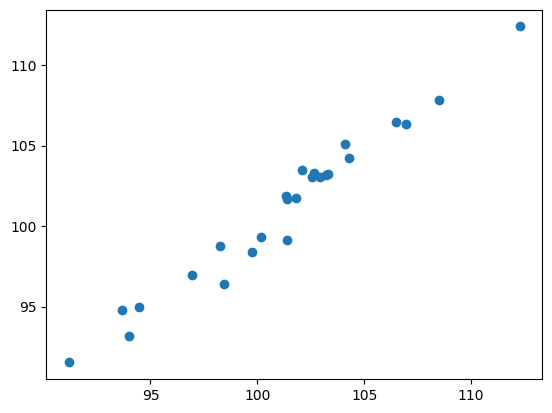

In [11]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(y, z)

# Vincent Sampling

In [13]:
print("="*80)
print("📊 Optimal Design Baseline (P_π matrix)")
print("="*80)

# Use pik_unequal as the inclusion probabilities
pik = pik_unequal  # or: pik = pik_equal

print(f"\nInclusion probabilities:")
print(f"   Type: Unequal (based on variable p)")
print(f"   Sum: {pik.sum():.2f}")
print(f"   Range: [{pik.min():.4f}, {pik.max():.4f}]")

# Optimal design
Base    = Ppi(pik)              # eigenbasis
Ppi_mat = Base @ Base.T         # K = P^Pi
Dpi_inv = np.diag(1.0 / pik)
I_N     = np.eye(N)

A = (I_N - Ppi_mat) * Ppi_mat   # K ⊙ (I - K)

var_dsd_z = float(z.T @ Dpi_inv @ A @ Dpi_inv @ z)
var_dsd_y = float(y.T @ Dpi_inv @ A @ Dpi_inv @ y)

# SRS variances
var_srs_z = N**2 * (1 - n / N) * np.var(z, ddof=1) / n
var_srs_y = N**2 * (1 - n / N) * np.var(y, ddof=1) / n

eff_y_optimal = var_srs_y / var_dsd_y
eff_z_optimal = var_srs_z / var_dsd_z

print(f"\n Variance comparison:")
print(f"   SRS:")
print(f"      var_y = {var_srs_y:.2f}")
print(f"      var_z = {var_srs_z:.2f}")
print(f"\n   Optimal DSD (P_π):")
print(f"      var_y = {var_dsd_y:.2f}")
print(f"      var_z = {var_dsd_z:.2f}")
print(f"\n   Efficiency:")
print(f"      eff_y = {eff_y_optimal:.2f}")
print(f"      eff_z = {eff_z_optimal:.2f}")

print(f"\n{'='*80}")
print(" Baseline established!")
print("="*80)

📊 Optimal Design Baseline (P_π matrix)

Inclusion probabilities:
   Type: Unequal (based on variable p)
   Sum: 5.00
   Range: [0.1724, 0.2269]

 Variance comparison:
   SRS:
      var_y = 2345.68
      var_z = 2391.09

   Optimal DSD (P_π):
      var_y = 1761.74
      var_z = 1916.69

   Efficiency:
      eff_y = 1.33
      eff_z = 1.25

 Baseline established!


In [15]:
print("="*80)
print(" Random Search with Detailed Tracking")
print("="*80)

import numpy as np
import pandas as pd

m_pi = np.array(pik, dtype=float)

# 1) sort π, y, z consistently
perm        = np.argsort(m_pi)[::-1]
m_pi_sorted = m_pi[perm]
y_sorted    = y[perm]
z_sorted    = z[perm]

N   = len(m_pi_sorted)
I_N = np.eye(N)

# 2) fixed size: M must equal n = sum(pi) (and be an integer)
n_target = m_pi_sorted.sum()
n_int    = int(round(n_target))

M = n_int

# Tracking statistics
stats = {
    'total_iterations': 0,
    'cadsd_success': 0,
    'cadsd_exception': 0,
    'diagonal_mismatch': 0,
    'eigenvalue_invalid': 0,
    'trace_invalid': 0,
    'all_checks_passed': 0,
}

max_eff_y = 0.0
max_eff_z = 0.0
best_K = None
num_iter = 10000

# Store some examples of failures
failure_examples = {
    'diagonal_mismatch': [],
    'eigenvalue_invalid': [],
    'trace_invalid': []
}

print(f"\nRunning {num_iter} iterations...")
print(f"Tracking where matrices fail validation...\n")

for it in range(num_iter):
    stats['total_iterations'] += 1
    
    omega = np.random.rand(M, N)
    rho   = np.random.rand(M, N - 1)
    
    # Stage 1: Try to construct K
    try:
        K = CaDsd(pi=m_pi_sorted, M=M, omega=omega, rho=rho)
        Kmat = K["K"].astype(np.complex128)
        stats['cadsd_success'] += 1
        
    except Exception as e:
        stats['cadsd_exception'] += 1
        if (it + 1) % 1000 == 0:
            print(f"iter {it+1:5d}: CaDsd exception: {str(e)[:50]}", end="\r")
        continue
    
    # Stage 2: Check diagonal
    diag_K = np.real(np.diag(Kmat))
    if not np.allclose(diag_K, m_pi_sorted, atol=1e-5):
        stats['diagonal_mismatch'] += 1
        
        # Store first 3 examples
        if len(failure_examples['diagonal_mismatch']) < 3:
            max_error = np.abs(diag_K - m_pi_sorted).max()
            failure_examples['diagonal_mismatch'].append({
                'iteration': it + 1,
                'max_diag_error': max_error,
                'prescribed_pi_sample': m_pi_sorted[:3].copy(),
                'actual_diag_sample': diag_K[:3].copy()
            })
        continue

    # Stage 3: Check eigenvalues
    evals = np.linalg.eigvalsh(Kmat)
    
    if not (np.all(evals >= -1e-5) and np.all(evals <= 1 + 1e-5)):
        stats['eigenvalue_invalid'] += 1
        
        # Store first 3 examples
        if len(failure_examples['eigenvalue_invalid']) < 3:
            failure_examples['eigenvalue_invalid'].append({
                'iteration': it + 1,
                'min_eigenvalue': evals.min(),
                'max_eigenvalue': evals.max(),
                'num_negative': (evals < -1e-5).sum(),
                'num_above_one': (evals > 1 + 1e-5).sum()
            })
        continue
    
    # Stage 4: Check trace
    if not np.isclose(evals.sum(), n_int, atol=1e-5):
        stats['trace_invalid'] += 1
        
        # Store first 3 examples
        if len(failure_examples['trace_invalid']) < 3:
            failure_examples['trace_invalid'].append({
                'iteration': it + 1,
                'trace': evals.sum(),
                'expected': n_int,
                'error': abs(evals.sum() - n_int)
            })
        continue
    
    # All checks passed!
    stats['all_checks_passed'] += 1
    
    # Calculate variances
    Dpi_inv = np.diag(1.0 / m_pi_sorted)
    A = Kmat * (I_N - Kmat.conj())
    
    var_y_rand = float(np.real(y_sorted.conj().T @ Dpi_inv @ A @ Dpi_inv @ y_sorted))
    var_z_rand = float(np.real(z_sorted.conj().T @ Dpi_inv @ A @ Dpi_inv @ z_sorted))
    
    eff_y_rand = var_srs_y / var_y_rand
    eff_z_rand = var_srs_z / var_z_rand
    
    if eff_z_rand > max_eff_z:
        max_eff_y = eff_y_rand
        max_eff_z = eff_z_rand
        best_K = Kmat.copy()
    
    if (it + 1) % 1000 == 0:
        print(f"iter {it+1:5d}: valid={stats['all_checks_passed']:4d} ({100*stats['all_checks_passed']/(it+1):.1f}%), "
              f"best_eff_z={max_eff_z:.2f}", end="\r")

print(f"\n\n{'='*80}")
print(" DETAILED STATISTICS")
print("="*80)

print(f"\nTotal iterations: {stats['total_iterations']}")
print(f"\n Stage-by-stage breakdown:")
print(f"   Stage 1 (CaDsd construction):")
print(f"       Success: {stats['cadsd_success']:5d} ({100*stats['cadsd_success']/stats['total_iterations']:5.1f}%)")
print(f"       Exception: {stats['cadsd_exception']:5d} ({100*stats['cadsd_exception']/stats['total_iterations']:5.1f}%)")

if stats['cadsd_success'] > 0:
    print(f"\n   Stage 2 (Diagonal check) - among {stats['cadsd_success']} constructed matrices:")
    passed_stage2 = stats['cadsd_success'] - stats['diagonal_mismatch']
    print(f"       Passed: {passed_stage2:5d} ({100*passed_stage2/stats['cadsd_success']:5.1f}%)")
    print(f"       Failed: {stats['diagonal_mismatch']:5d} ({100*stats['diagonal_mismatch']/stats['cadsd_success']:5.1f}%)")
    
    if passed_stage2 > 0:
        print(f"\n   Stage 3 (Eigenvalue check) - among {passed_stage2} passed stage 2:")
        passed_stage3 = passed_stage2 - stats['eigenvalue_invalid']
        print(f"       Passed: {passed_stage3:5d} ({100*passed_stage3/passed_stage2:5.1f}%)")
        print(f"       Failed: {stats['eigenvalue_invalid']:5d} ({100*stats['eigenvalue_invalid']/passed_stage2:5.1f}%)")
        
        if passed_stage3 > 0:
            print(f"\n   Stage 4 (Trace check) - among {passed_stage3} passed stage 3:")
            print(f"       Passed: {stats['all_checks_passed']:5d} ({100*stats['all_checks_passed']/passed_stage3:5.1f}%)")
            print(f"       Failed: {stats['trace_invalid']:5d} ({100*stats['trace_invalid']/passed_stage3:5.1f}%)")

print(f"\n Final result:")
print(f"   Valid matrices: {stats['all_checks_passed']}/{stats['total_iterations']} ({100*stats['all_checks_passed']/stats['total_iterations']:.2f}%)")

print(f"\n{'='*80}")
print(" FAILURE EXAMPLES (First 3 of each type)")
print("="*80)

# Diagonal mismatch examples
if failure_examples['diagonal_mismatch']:
    print(f"\n Diagonal Mismatch Examples:")
    for i, ex in enumerate(failure_examples['diagonal_mismatch'], 1):
        print(f"\n   Example {i} (iteration {ex['iteration']}):")
        print(f"      Max diagonal error: {ex['max_diag_error']:.2e}")
        print(f"      Prescribed π (first 3): {ex['prescribed_pi_sample']}")
        print(f"      Actual diag(K) (first 3): {ex['actual_diag_sample']}")

# Eigenvalue invalid examples
if failure_examples['eigenvalue_invalid']:
    print(f"\n Eigenvalue Invalid Examples:")
    for i, ex in enumerate(failure_examples['eigenvalue_invalid'], 1):
        print(f"\n   Example {i} (iteration {ex['iteration']}):")
        print(f"      Min eigenvalue: {ex['min_eigenvalue']:.6f} (should be >= 0)")
        print(f"      Max eigenvalue: {ex['max_eigenvalue']:.6f} (should be <= 1)")
        print(f"      Count < 0: {ex['num_negative']}")
        print(f"      Count > 1: {ex['num_above_one']}")

# Trace invalid examples
if failure_examples['trace_invalid']:
    print(f"\n Trace Invalid Examples:")
    for i, ex in enumerate(failure_examples['trace_invalid'], 1):
        print(f"\n   Example {i} (iteration {ex['iteration']}):")
        print(f"      Trace (sum of eigenvalues): {ex['trace']:.6f}")
        print(f"      Expected (n): {ex['expected']}")
        print(f"      Error: {ex['error']:.2e}")

print(f"\n{'='*80}")
print(" ANSWER TO PROFESSOR'S QUESTION")
print("="*80)

print(f"\n Question: Are bad matrices constructed and then rejected,")
print(f"             or are they never constructed at all?")

if stats['cadsd_exception'] > 0:
    print(f"\n Answer: BOTH scenarios occur!")
    print(f"   - {stats['cadsd_exception']} ({100*stats['cadsd_exception']/stats['total_iterations']:.1f}%) "
          f"matrices failed to construct (CaDsd exception)")
    print(f"   - {stats['cadsd_success'] - stats['all_checks_passed']} "
          f"({100*(stats['cadsd_success'] - stats['all_checks_passed'])/stats['total_iterations']:.1f}%) "
          f"matrices were constructed but failed validation")
else:
    print(f"\n Answer: Bad matrices ARE constructed!")
    print(f"   - ALL {stats['total_iterations']} attempts successfully constructed a matrix")
    print(f"   - But {stats['cadsd_success'] - stats['all_checks_passed']} "
          f"({100*(stats['cadsd_success'] - stats['all_checks_passed'])/stats['cadsd_success']:.1f}%) "
          f"were rejected due to validation failures")

print(f"\n Validation failure breakdown (among constructed matrices):")
if stats['cadsd_success'] > 0:
    print(f"   - Diagonal mismatch: {stats['diagonal_mismatch']:5d} "
          f"({100*stats['diagonal_mismatch']/stats['cadsd_success']:5.1f}%)")
    print(f"   - Eigenvalue invalid: {stats['eigenvalue_invalid']:5d} "
          f"({100*stats['eigenvalue_invalid']/stats['cadsd_success']:5.1f}%)")
    print(f"   - Trace invalid: {stats['trace_invalid']:5d} "
          f"({100*stats['trace_invalid']/stats['cadsd_success']:5.1f}%)")

print(f"\n{'='*80}")
print(" Investigation complete!")
print("="*80)

# Store best_K for later use
if best_K is not None:
    print(f"\n Best design found:")
    print(f"   Efficiency (z): {max_eff_z:.2f}")
    print(f"   Efficiency (y): {max_eff_y:.2f}")
    best_K_equal = best_K
    print("\n   Diagonal check:")
    print(pd.DataFrame({
        'pik': m_pi_sorted,
        'diag': np.real(np.diag(best_K)),
        'eign': np.linalg.eigvalsh(best_K)
    }))
else:
    print("\n  No valid design found!")

 Random Search with Detailed Tracking

Running 10000 iterations...
Tracking where matrices fail validation...

iter  9000: valid= 927 (10.3%), best_eff_z=2.09

 DETAILED STATISTICS

Total iterations: 10000

 Stage-by-stage breakdown:
   Stage 1 (CaDsd construction):
       Success: 10000 (100.0%)
       Exception:     0 (  0.0%)

   Stage 2 (Diagonal check) - among 10000 constructed matrices:
       Passed:  3064 ( 30.6%)
       Failed:  6936 ( 69.4%)

   Stage 3 (Eigenvalue check) - among 3064 passed stage 2:
       Passed:  1260 ( 41.1%)
       Failed:  1804 ( 58.9%)

   Stage 4 (Trace check) - among 1260 passed stage 3:
       Passed:  1032 ( 81.9%)
       Failed:   228 ( 18.1%)

 Final result:
   Valid matrices: 1032/10000 (10.32%)

 FAILURE EXAMPLES (First 3 of each type)

 Diagonal Mismatch Examples:

   Example 1 (iteration 1):
      Max diagonal error: 1.53e-04
      Prescribed π (first 3): [0.22689636 0.21753987 0.21623492]
      Actual diag(K) (first 3): [0.2268964 0.2175398 

In [16]:
best_K

array([[ 2.268964e-01+0.000000e+00j,  6.324650e-02-8.442710e-02j,
         1.850150e-02+7.230900e-03j,  1.291432e-01-9.010390e-02j,
        -7.993470e-02-7.993970e-02j,  1.658340e-02-6.171720e-02j,
        -4.948350e-02-1.528120e-02j,  5.709380e-02-1.386959e-01j,
        -4.682340e-02-7.025160e-02j,  3.988460e-02+4.033170e-02j,
         1.764900e-02+4.127080e-02j, -3.085550e-02+9.270800e-03j,
         6.609840e-02+6.864200e-02j,  2.362300e-03-3.580440e-02j,
         5.373030e-02-1.243140e-02j,  4.381540e-02+4.272100e-03j,
         1.816700e-03-6.508990e-02j,  3.499580e-02+3.807660e-02j,
         7.118660e-02+7.475530e-02j,  3.518000e-03+3.272100e-02j,
        -4.197500e-02-9.046710e-02j, -1.213456e-01-4.288100e-03j,
        -7.438340e-02-8.517830e-02j,  4.522500e-02-8.031630e-02j,
         4.930140e-02+3.534460e-02j],
       [ 6.324650e-02+8.442710e-02j,  2.175398e-01+0.000000e+00j,
         1.595053e-01+8.590040e-02j,  6.086500e-03-5.327310e-02j,
         8.849340e-02+6.083230e-02j,  

What need we sent to Vincent, a population of size 25, a sample of size 5, with equal and unequal probabilies
we need to send the best metrix, intiial, variable y and z and the variation of HT estimator. In R format.

# Sensitivity Analysis

In [16]:
import pandas as pd
def sensitivity_analysis_uniform(
    best_omega, 
    best_rho, 
    pik_sorted,
    y_sorted, 
    z_sorted,
    var_srs_y,
    var_srs_z,
    best_var_y,
    best_var_z,
    epsilon=0.01, 
    num_perturbations=100, 
    case_name="EQUAL"
):
    
    M, N = best_omega.shape
    I_N = np.eye(N)
    Dpi_inv = np.diag(1.0 / pik_sorted)
    n = int(round(pik_sorted.sum()))
    
    results = []
    
    print(f"\n{'='*80}")
    print(f" UNIFORM SENSITIVITY ANALYSIS: {case_name} (epsilon={epsilon})")
    print(f"{'='*80}")
    print(f"   Best var_y: {best_var_y:.4f}")
    print(f"   Best var_z: {best_var_z:.4f}")
    
    # حالات مختلف تغییرات یکنواخت
    perturbation_cases = [
        ("omega+, rho+", +epsilon, +epsilon),
        ("omega+, rho-", +epsilon, -epsilon),
        ("omega-, rho+", -epsilon, +epsilon),
        ("omega-, rho-", -epsilon, -epsilon),
        ("omega+, rho=0", +epsilon, 0),
        ("omega-, rho=0", -epsilon, 0),
        ("omega=0, rho+", 0, +epsilon),
        ("omega=0, rho-", 0, -epsilon),
    ]
    
    print(f"\n   Testing {len(perturbation_cases)} uniform perturbation cases:")
    
    for case_name_detail, delta_omega, delta_rho in perturbation_cases:
        # Apply uniform perturbation
        omega_new = best_omega + delta_omega
        rho_new = best_rho + delta_rho
        
        # Clip to [0, 1]
        omega_new = np.clip(omega_new, 0.0, 1.0)
        rho_new = np.clip(rho_new, 0.0, 1.0)
        
        try:
            # Build new K
            K_dict = CaDsd(pi=pik_sorted, M=M, omega=omega_new, rho=rho_new)
            Kmat = K_dict["K"].astype(np.complex128)
            
            # Validation checks
            diag_K = np.real(np.diag(Kmat))
            if not np.allclose(diag_K, pik_sorted, atol=1e-5):
                results.append({
                    'perturbation_type': case_name_detail,
                    'delta_omega': delta_omega,
                    'delta_rho': delta_rho,
                    'var_y': np.nan,
                    'var_z': np.nan,
                    'delta_var_y': np.nan,
                    'delta_var_z': np.nan,
                    'valid': False,
                    'reason': 'diagonal mismatch'
                })
                print(f"       {case_name_detail:20s} → Invalid (diagonal)")
                continue
            
            evals = np.linalg.eigvalsh(Kmat)
            if not (np.all(evals >= -1e-5) and np.all(evals <= 1 + 1e-5)):
                results.append({
                    'perturbation_type': case_name_detail,
                    'delta_omega': delta_omega,
                    'delta_rho': delta_rho,
                    'var_y': np.nan,
                    'var_z': np.nan,
                    'delta_var_y': np.nan,
                    'delta_var_z': np.nan,
                    'valid': False,
                    'reason': 'eigenvalues out of [0,1]'
                })
                print(f"       {case_name_detail:20s} → Invalid (eigenvalues)")
                continue
            
            if not np.isclose(evals.sum(), n, atol=1e-5):
                results.append({
                    'perturbation_type': case_name_detail,
                    'delta_omega': delta_omega,
                    'delta_rho': delta_rho,
                    'var_y': np.nan,
                    'var_z': np.nan,
                    'delta_var_y': np.nan,
                    'delta_var_z': np.nan,
                    'valid': False,
                    'reason': 'trace != n'
                })
                print(f"       {case_name_detail:20s} → Invalid (trace)")
                continue
            
            # Calculate variances
            A = Kmat * (I_N - Kmat.conj())
            var_y_new = float(np.real(y_sorted.conj().T @ Dpi_inv @ A @ Dpi_inv @ y_sorted))
            var_z_new = float(np.real(z_sorted.conj().T @ Dpi_inv @ A @ Dpi_inv @ z_sorted))
            
            delta_var_y = abs(var_y_new - best_var_y)
            delta_var_z = abs(var_z_new - best_var_z)
            
            results.append({
                'perturbation_type': case_name_detail,
                'delta_omega': delta_omega,
                'delta_rho': delta_rho,
                'var_y': var_y_new,
                'var_z': var_z_new,
                'delta_var_y': delta_var_y,
                'delta_var_z': delta_var_z,
                'valid': True,
                'reason': 'OK'
            })
            
            print(f"       {case_name_detail:20s} → Δvar_y={delta_var_y:8.4f}, Δvar_z={delta_var_z:8.4f}")
            
        except Exception as e:
            results.append({
                'perturbation_type': case_name_detail,
                'delta_omega': delta_omega,
                'delta_rho': delta_rho,
                'var_y': np.nan,
                'var_z': np.nan,
                'delta_var_y': np.nan,
                'delta_var_z': np.nan,
                'valid': False,
                'reason': f'Exception: {str(e)[:30]}'
            })
            print(f"       {case_name_detail:20s} → Exception: {str(e)[:40]}")
    
    df = pd.DataFrame(results)
    
    # Statistics
    df_valid = df[df['valid'] == True]
    num_valid = len(df_valid)
    num_total = len(df)
    
    print(f"\n    Completed!")
    print(f"      Valid designs: {num_valid}/{num_total} ({100*num_valid/num_total:.1f}%)")
    
    if num_valid > 0:
        print(f"\n    Statistics (valid designs only):")
        print(f"      delta_var_y: mean={df_valid['delta_var_y'].mean():.4f}, std={df_valid['delta_var_y'].std():.4f}")
        print(f"                   min={df_valid['delta_var_y'].min():.4f}, max={df_valid['delta_var_y'].max():.4f}")
        print(f"      delta_var_z: mean={df_valid['delta_var_z'].mean():.4f}, std={df_valid['delta_var_z'].std():.4f}")
        print(f"                   min={df_valid['delta_var_z'].min():.4f}, max={df_valid['delta_var_z'].max():.4f}")
    
    return df

print("Uniform sensitivity analysis function loaded!")

Uniform sensitivity analysis function loaded!


In [17]:
# Uniform sensitivity analysis for EQUAL case (epsilon = 0.01)
if best_K_equal is not None and best_omega_equal is not None:
    # Calculate best variances
    Dpi_inv_eq = np.diag(1.0 / pik_equal_sorted)
    A_best_eq = best_K_equal * (I_N - best_K_equal.conj())
    best_var_y_eq = float(np.real(y_sorted.conj().T @ Dpi_inv_eq @ A_best_eq @ Dpi_inv_eq @ y_sorted))
    best_var_z_eq = float(np.real(z_sorted.conj().T @ Dpi_inv_eq @ A_best_eq @ Dpi_inv_eq @ z_sorted))
    
    df_uniform_equal_001 = sensitivity_analysis_uniform(
        best_omega=best_omega_equal,
        best_rho=best_rho_equal,
        pik_sorted=pik_equal_sorted,
        y_sorted=y_sorted,
        z_sorted=z_sorted,
        var_srs_y=var_srs_y,
        var_srs_z=var_srs_z,
        best_var_y=best_var_y_eq,
        best_var_z=best_var_z_eq,
        epsilon=0.01,
        case_name="EQUAL"
    )
else:
    print("  No best design found for EQUAL case!")
    


 UNIFORM SENSITIVITY ANALYSIS: EQUAL (epsilon=0.01)
   Best var_y: 1925.5857
   Best var_z: 1991.9218

   Testing 8 uniform perturbation cases:
       omega+, rho+         → Invalid (eigenvalues)
       omega+, rho-         → Invalid (eigenvalues)
       omega-, rho+         → Invalid (diagonal)
       omega-, rho-         → Invalid (diagonal)
       omega+, rho=0        → Invalid (eigenvalues)
       omega-, rho=0        → Invalid (diagonal)
       omega=0, rho+        → Δvar_y=249.8705, Δvar_z=283.3826
       omega=0, rho-        → Δvar_y=250.2519, Δvar_z=283.4443

    Completed!
      Valid designs: 2/8 (25.0%)

    Statistics (valid designs only):
      delta_var_y: mean=250.0612, std=0.2697
                   min=249.8705, max=250.2519
      delta_var_z: mean=283.4135, std=0.0436
                   min=283.3826, max=283.4443


In [18]:
# Uniform sensitivity analysis for EQUAL case (epsilon = 0.02)
if best_K_equal is not None and best_omega_equal is not None:
    df_uniform_equal_002 = sensitivity_analysis_uniform(
        best_omega=best_omega_equal,
        best_rho=best_rho_equal,
        pik_sorted=pik_equal_sorted,
        y_sorted=y_sorted,
        z_sorted=z_sorted,
        var_srs_y=var_srs_y,
        var_srs_z=var_srs_z,
        best_var_y=best_var_y_eq,
        best_var_z=best_var_z_eq,
        epsilon=0.02,
        case_name="EQUAL"
    )
    


 UNIFORM SENSITIVITY ANALYSIS: EQUAL (epsilon=0.02)
   Best var_y: 1925.5857
   Best var_z: 1991.9218

   Testing 8 uniform perturbation cases:
       omega+, rho+         → Invalid (diagonal)
       omega+, rho-         → Invalid (diagonal)
       omega-, rho+         → Invalid (diagonal)
       omega-, rho-         → Invalid (diagonal)
       omega+, rho=0        → Invalid (diagonal)
       omega-, rho=0        → Invalid (diagonal)
       omega=0, rho+        → Δvar_y=249.5550, Δvar_z=283.4347
       omega=0, rho-        → Δvar_y=250.2340, Δvar_z=283.4254

    Completed!
      Valid designs: 2/8 (25.0%)

    Statistics (valid designs only):
      delta_var_y: mean=249.8945, std=0.4801
                   min=249.5550, max=250.2340
      delta_var_z: mean=283.4301, std=0.0066
                   min=283.4254, max=283.4347


In [19]:
# Uniform sensitivity analysis for UNEQUAL case (epsilon = 0.01)
if best_K_unequal is not None and best_omega_unequal is not None:
    # Calculate best variances
    Dpi_inv_uneq = np.diag(1.0 / pik_unequal_sorted)
    A_best_uneq = best_K_unequal * (I_N - best_K_unequal.conj())
    best_var_y_uneq = float(np.real(y_sorted_uneq.conj().T @ Dpi_inv_uneq @ A_best_uneq @ Dpi_inv_uneq @ y_sorted_uneq))
    best_var_z_uneq = float(np.real(z_sorted_uneq.conj().T @ Dpi_inv_uneq @ A_best_uneq @ Dpi_inv_uneq @ z_sorted_uneq))
    
    df_uniform_unequal_001 = sensitivity_analysis_uniform(
        best_omega=best_omega_unequal,
        best_rho=best_rho_unequal,
        pik_sorted=pik_unequal_sorted,
        y_sorted=y_sorted_uneq,
        z_sorted=z_sorted_uneq,
        var_srs_y=var_srs_y,
        var_srs_z=var_srs_z,
        best_var_y=best_var_y_uneq,
        best_var_z=best_var_z_uneq,
        epsilon=0.01,
        case_name="UNEQUAL"
    )
else:
    print("  No best design found for UNEQUAL case!")


 UNIFORM SENSITIVITY ANALYSIS: UNEQUAL (epsilon=0.01)
   Best var_y: 1042.5962
   Best var_z: 1172.9373

   Testing 8 uniform perturbation cases:
       omega+, rho+         → Invalid (eigenvalues)
       omega+, rho-         → Invalid (eigenvalues)
       omega-, rho+         → Invalid (diagonal)
       omega-, rho-         → Invalid (diagonal)
       omega+, rho=0        → Invalid (eigenvalues)
       omega-, rho=0        → Invalid (diagonal)
       omega=0, rho+        → Δvar_y=  0.0545, Δvar_z=  0.0550
       omega=0, rho-        → Δvar_y=  0.0894, Δvar_z=  0.0898

    Completed!
      Valid designs: 2/8 (25.0%)

    Statistics (valid designs only):
      delta_var_y: mean=0.0719, std=0.0247
                   min=0.0545, max=0.0894
      delta_var_z: mean=0.0724, std=0.0246
                   min=0.0550, max=0.0898


In [20]:
# Uniform sensitivity analysis for UNEQUAL case (epsilon = 0.02)
if best_K_unequal is not None and best_omega_unequal is not None:
    df_uniform_unequal_002 = sensitivity_analysis_uniform(
        best_omega=best_omega_unequal,
        best_rho=best_rho_unequal,
        pik_sorted=pik_unequal_sorted,
        y_sorted=y_sorted_uneq,
        z_sorted=z_sorted_uneq,
        var_srs_y=var_srs_y,
        var_srs_z=var_srs_z,
        best_var_y=best_var_y_uneq,
        best_var_z=best_var_z_uneq,
        epsilon=0.02,
        case_name="UNEQUAL"
    )
    


 UNIFORM SENSITIVITY ANALYSIS: UNEQUAL (epsilon=0.02)
   Best var_y: 1042.5962
   Best var_z: 1172.9373

   Testing 8 uniform perturbation cases:
       omega+, rho+         → Invalid (diagonal)
       omega+, rho-         → Invalid (diagonal)
       omega-, rho+         → Invalid (diagonal)
       omega-, rho-         → Invalid (diagonal)
       omega+, rho=0        → Invalid (diagonal)
       omega-, rho=0        → Invalid (diagonal)
       omega=0, rho+        → Δvar_y=  0.0814, Δvar_z=  0.2485
       omega=0, rho-        → Δvar_y=  1.6560, Δvar_z=  1.7279

    Completed!
      Valid designs: 2/8 (25.0%)

    Statistics (valid designs only):
      delta_var_y: mean=0.8687, std=1.1134
                   min=0.0814, max=1.6560
      delta_var_z: mean=0.9882, std=1.0461
                   min=0.2485, max=1.7279


In [22]:
print("\n" + "="*80)
print(" UNIFORM PERTURBATION RESULTS SUMMARY")
print("="*80)

# Combine all results
all_results = []

# EQUAL - epsilon 0.01
if 'df_uniform_equal_001' in locals():
    df_temp = df_uniform_equal_001.copy()
    df_temp['case'] = 'EQUAL'
    df_temp['epsilon'] = 0.01
    all_results.append(df_temp)

# EQUAL - epsilon 0.02
if 'df_uniform_equal_002' in locals():
    df_temp = df_uniform_equal_002.copy()
    df_temp['case'] = 'EQUAL'
    df_temp['epsilon'] = 0.02
    all_results.append(df_temp)

# UNEQUAL - epsilon 0.01
if 'df_uniform_unequal_001' in locals():
    df_temp = df_uniform_unequal_001.copy()
    df_temp['case'] = 'UNEQUAL'
    df_temp['epsilon'] = 0.01
    all_results.append(df_temp)

# UNEQUAL - epsilon 0.02
if 'df_uniform_unequal_002' in locals():
    df_temp = df_uniform_unequal_002.copy()
    df_temp['case'] = 'UNEQUAL'
    df_temp['epsilon'] = 0.02
    all_results.append(df_temp)

if all_results:
    df_all_uniform = pd.concat(all_results, ignore_index=True)
    
    # Show all results
    print("\n Complete Results Table:")
    print(df_all_uniform[['case', 'epsilon', 'perturbation_type', 
                          'delta_var_y', 'delta_var_z', 'valid', 'reason']].to_string(index=False))
    
    # Summary statistics
    print("\n" + "="*80)
    print(" SUMMARY BY CASE AND EPSILON")
    print("="*80)
    
    for case in ['EQUAL', 'UNEQUAL']:
        for eps in [0.01, 0.02]:
            df_subset = df_all_uniform[(df_all_uniform['case'] == case) & 
                                       (df_all_uniform['epsilon'] == eps)]
            df_valid = df_subset[df_subset['valid'] == True]
            
            print(f"\n{case}, ε={eps}:")
            print(f"   Valid: {len(df_valid)}/{len(df_subset)} ({100*len(df_valid)/len(df_subset):.1f}%)")
            
            if len(df_valid) > 0:
                print(f"   Δvar_y: mean={df_valid['delta_var_y'].mean():.4f}, "
                      f"min={df_valid['delta_var_y'].min():.4f}, "
                      f"max={df_valid['delta_var_y'].max():.4f}")
                print(f"   Δvar_z: mean={df_valid['delta_var_z'].mean():.4f}, "
                      f"min={df_valid['delta_var_z'].min():.4f}, "
                      f"max={df_valid['delta_var_z'].max():.4f}")
else:
    print("  No results available!")

print("\n" + "="*80)
print(" Uniform sensitivity analysis complete!")
print("="*80)


 UNIFORM PERTURBATION RESULTS SUMMARY

 Complete Results Table:
   case  epsilon perturbation_type  delta_var_y  delta_var_z  valid                   reason
  EQUAL     0.01      omega+, rho+          NaN          NaN  False eigenvalues out of [0,1]
  EQUAL     0.01      omega+, rho-          NaN          NaN  False eigenvalues out of [0,1]
  EQUAL     0.01      omega-, rho+          NaN          NaN  False        diagonal mismatch
  EQUAL     0.01      omega-, rho-          NaN          NaN  False        diagonal mismatch
  EQUAL     0.01     omega+, rho=0          NaN          NaN  False eigenvalues out of [0,1]
  EQUAL     0.01     omega-, rho=0          NaN          NaN  False        diagonal mismatch
  EQUAL     0.01     omega=0, rho+   249.870501   283.382623   True                       OK
  EQUAL     0.01     omega=0, rho-   250.251933   283.444311   True                       OK
  EQUAL     0.02      omega+, rho+          NaN          NaN  False        diagonal mismatch
  EQU

# For Searching around an efficient K

In [17]:
eps_omega = 0.02   # step size
eps_rho   = 0.02

omega_new = omega0 + eps_omega * (2 * np.random.rand(*omega0.shape) - 1)
rho_new   = rho0   + eps_rho   * (2 * np.random.rand(*rho0.shape) - 1)

# keep them in [0,1]
omega_new = np.clip(omega_new, 0.0, 1.0)
rho_new   = np.clip(rho_new,   0.0, 1.0)


SyntaxError: invalid syntax (707667070.py, line 5)

In [ ]:
K = CaDsd(pi=m_pi_sorted, M=M, omega=omega_new, rho=rho_new)
Kmat = K["K"].astype(np.complex128)
Kmat = 0.5 * (Kmat + Kmat.conj().T)             # enforce Hermitian

diag_K = np.real(np.diag(Kmat))
if not np.allclose(diag_K, m_pi_sorted, atol=1e-6):
    reject  # π not respected

evals = np.linalg.eigvalsh(Kmat)
if not (np.all(evals >= -1e-6) and np.all(evals <= 1 + 1e-6)):
    reject  # not contracting / projection-like


In [ ]:
Dpi_inv = np.diag(1.0 / m_pi_sorted)
A = Kmat * (I_N - Kmat.conj())

var_y = float(np.real(y_sorted.conj().T @ Dpi_inv @ A @ Dpi_inv @ y_sorted))
var_z = float(np.real(z_sorted.conj().T @ Dpi_inv @ A @ Dpi_inv @ z_sorted))
